# Challenge 10: Linear least squares vs polynomial fit

Part A:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
def mse(y, y_pred):
    result = np.mean((y-y_pred)**2)
    return result
    
def rSq(y, y_pred):
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_pred)**2)
    r_squared = 1 - (ss_res / ss_total)
    return r_squared

In [3]:
m = 2.3
b = 0.62
x = np.arange(0, 10.1, 0.1)
y = m*x + b
noise = [random.uniform(-10, 10) for i in range(len(y))]
y = noise + y

In [19]:
x.sort()
A = np.vstack([x, np.ones(len(x))]).T
m, c = np.linalg.lstsq(A, y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")
y_line = m*x + c

coef = np.polyfit(x, y, 3)
poly1 = np.poly1d(coef)
y_poly = poly1(x)

print(mse(y, y_line))
print(mse(y, y_poly))
print(rSq(y, y_line))
print(rSq(y, y_poly))

Slope: 2.2980787292300793, Intercept: 0.38583324219882603
33.822887676293846
33.80365553148048
0.5703000171697838
0.5705443503081955


The 3rd degree polynomial basically has the same mse and rsq values as the line since the data is based on a linear equation. This shows that a polynomial of degree 1-3 will have a good correlation without overfitting.

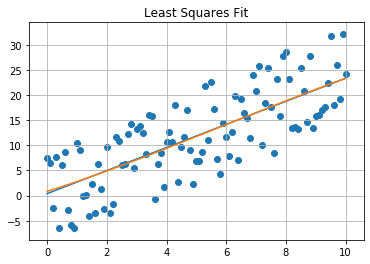

In [20]:
plt.plot(x, y_line)
plt.plot(x, y_poly)
plt.scatter(x, y)
plt.title("Least Squares Fit")
plt.grid(True)
plt.show()

Part B:

In [6]:
for i in range(18):
    coef = np.polyfit(x, y, i)
    poly2 = np.poly1d(coef)
    y_poly2 = poly2(x)
    print(i, mse(y, y_poly2), rSq(y, y_poly2))

0 78.71279736508161 0.0
1 33.82288767629384 0.5703000171697841
2 33.812199392218105 0.5704358055604082
3 33.80365553148048 0.5705443503081955
4 33.519495051025295 0.5741544428213252
5 33.28718470269065 0.5771058097668698
6 30.817412796903543 0.6084828156472725
7 30.661633717498773 0.6104618976341856
8 30.33577156429082 0.614601785481095
9 30.297086020277593 0.6150932626653425
10 30.278846211319127 0.615324988757783
11 29.647501877037918 0.6233458488391868
12 29.419582902707038 0.626241425949396
13 29.40118222542513 0.6264751957796888
14 29.177665621869316 0.629314843347023
15 29.133544980045695 0.629875370266413
16 28.98974848785642 0.6317022204991944
17 28.93205021273033 0.6324352432992668


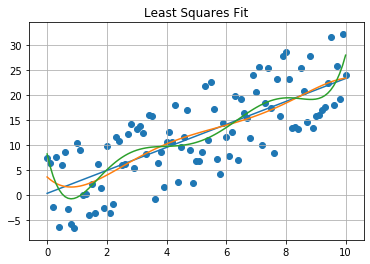

In [22]:
coef1 = np.polyfit(x, y, 5)
poly1 = np.poly1d(coef1)
y_poly1 = poly1(x)

coef2 = np.polyfit(x, y, 6)
poly2 = np.poly1d(coef2)
y_poly2 = poly2(x)

plt.plot(x, y_line)
plt.plot(x, y_poly1)
plt.plot(x, y_poly2)
plt.scatter(x, y)
plt.title("Least Squares Fit")
plt.grid(True)
plt.show()

I chose to show the difference between degree 5 and 6 because there seemed to be a big jump in mse and rsq values between the two. you can see that the degree 5 in orange is still close to the linear regression the data points are based on while the degree 6 is more sporadic.

On the other hand, since the data is based on a line, the degree 1 polynomial will be fine but a degree 0 polynomial will be undefitting

Part C:

In [73]:
def vandermonde_matrix(x, degree):
    n = len(x)
    V = np.zeros((n, degree + 1))
    for i in range(n):
        for j in range(degree + 1):
            V[i][j] = x[i] ** j
    return V

def polynomial_fit(x, y, degree):
    V = vandermonde_matrix(x, degree)
    VT_V = np.dot(V.T, V)
    VT_y = np.dot(V.T, y)
    coefficients = np.linalg.solve(VT_V, VT_y)
    return coefficients


In [64]:
print(create_vandermonde_matrix(2))

[[1. 1. 1.]
 [1. 2. 4.]
 [1. 3. 9.]]


In [75]:
a = polynomial_fit(x, y, 3)
coef = np.polyfit(x, y, 3)

print(a)
print(coef)

[ 0.84068818  1.87845916  0.0848581  -0.00475051]
[-0.00475051  0.0848581   1.87845916  0.84068818]
